In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [27]:
# Load the entire JSON file
with open("../data/raw/app_1903340.json", 'r', encoding='utf-8') as f:
    app_data = pd.read_json(f, typ='series')

# Extract app metadata (everything except reviews)
app_info = app_data.drop('reviews')

# Extract reviews into a DataFrame
df = pd.json_normalize(app_data['reviews'])

# Convert timestamps to human-readable datetime format
df['timestamp_created'] = pd.to_datetime(df['timestamp_created'], unit='s')
df['timestamp_updated'] = pd.to_datetime(df['timestamp_updated'], unit='s')
df['author.last_played'] = pd.to_datetime(df['author.last_played'], unit='s')
df = df.sort_values('votes_funny', ascending=False)

# Display app info
print(f"App: {app_info['name']}")
print(f"App ID: {app_info['steam_appid']}")
print(f"Total reviews loaded: {len(df)}")


App: Clair Obscur: Expedition 33
App ID: 1903340
Total reviews loaded: 5034


In [28]:
df.head(20)

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,written_during_early_access,primarily_steam_deck,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played,author.deck_playtime_at_review
89,193645433,english,"Lost Odyssey, Nier, and Shadow Hearts tossed i...",2025-04-26 17:49:56,2025-04-26 17:49:56,True,1956,781,0.927287161350250244,51,...,False,False,76561197994422823,0,14,6550,0,912,2025-12-13 08:54:49,NaN
23,193462193,english,God this game is amazing the soundtrack is bea...,2025-04-24 07:46:30,2025-04-25 10:41:36,True,2260,658,0.935826122760772705,37,...,False,False,76561199095821353,408,41,3950,0,930,2025-05-22 09:31:09,NaN
90,209178049,english,If this doesn't win GOTY I will shove 33 esqui...,2025-11-14 07:34:35,2025-11-14 13:09:57,True,1040,333,0.872560322284698486,55,...,False,False,76561198143650483,0,1,1873,0,1873,2025-05-13 17:22:56,NaN
1099,206004485,english,Took me 10 minutes to beat the main menu. Incr...,2025-10-06 01:59:36,2025-10-06 01:59:36,False,116,307,0.556167662143707275,6,...,False,False,76561198076610409,162,13,5509,0,5365,2025-12-14 21:28:28,NaN
2728,193530823,english,"I was hyped for this game, I saw a few picture...",2025-04-25 05:31:07,2025-04-25 05:31:07,False,1035,296,0.539874613285064697,0,...,False,False,76561198087038785,0,11,1738,0,347,2025-05-07 11:36:43,NaN
83,212307168,english,"Absolutely incredible game, GOTY 2025 and prob...",2025-12-01 13:45:49,2025-12-01 13:45:49,True,891,270,0.833647727966308594,13,...,False,False,76561198165306740,370,48,3323,0,3323,2025-06-04 21:05:45,NaN
0,193461305,english,When 30 (!) French devs escape from Ubisoft to...,2025-04-24 07:21:40,2025-11-25 08:16:42,True,12057,211,0.979400813579559326,193,...,False,False,76561198070333442,181,8,5510,0,5510,2025-09-04 11:42:16,NaN
1,209347066,english,Clair Obscur feels like one of those games tha...,2025-11-16 02:34:02,2025-12-07 03:17:03,True,8040,159,0.974822461605072021,71,...,False,False,76561198212351161,1744,131,3556,0,3556,2025-11-16 02:12:48,NaN
70,193460770,english,[h3]Getting to play this and Oblivion Remaster...,2025-04-24 07:06:10,2025-04-24 17:29:08,True,1142,111,0.854688048362731934,19,...,False,False,76561198038931832,0,158,1933,0,85,2025-05-13 06:39:01,NaN
64,193967238,english,"Visually stunning, musically magical, and the ...",2025-05-01 10:53:32,2025-05-08 14:54:24,True,672,91,0.912267565727233887,16,...,False,False,76561198049677833,2258,28,5543,0,2220,2025-05-24 01:25:31,NaN


In [29]:
df.tail(20)

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,written_during_early_access,primarily_steam_deck,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played,author.deck_playtime_at_review
5030,216135431,english,best game of the decade,2026-01-17 04:54:31,2026-01-17 04:54:31,True,0,0,0.5,0,...,False,False,76561199494241006,22,3,3204,0,3204,2026-01-11 03:54:37,NaN
5031,216134766,english,Genuine masterpiece.\r\nAnd very French.,2026-01-17 04:40:17,2026-01-17 04:40:17,True,0,0,0.5,0,...,False,False,76561198309367050,0,3,4909,398,4909,2026-01-17 04:38:21,NaN
5032,216134438,english,Devastating. Would recommend.,2026-01-17 04:33:27,2026-01-17 04:33:27,True,0,0,0.5,0,...,False,False,76561198145007975,0,4,2613,122,2613,2026-01-17 04:23:25,NaN
4986,216148969,english,"Amazing game, best narrative experience in a l...",2026-01-17 09:49:18,2026-01-17 09:49:18,True,0,0,0.5,0,...,False,False,76561197965165383,427,14,2035,1161,1172,2026-01-19 20:40:27,NaN
539,194847108,english,This game is a masterclass piece of art\n\nFro...,2025-05-13 22:41:35,2025-05-13 22:41:35,True,19,0,0.579023957252502441,1,...,False,False,76561198281700290,250,6,7977,0,7848,2026-01-01 16:23:59,NaN
541,199453435,english,if you've played a lot of games. you will real...,2025-07-10 13:35:53,2025-07-10 13:35:53,True,5,0,0.578833699226379395,0,...,False,False,76561198185685646,0,42,3860,0,3725,2025-07-31 05:10:05,NaN
542,194765358,english,Hypnotically European setting. The characters ...,2025-05-12 17:13:58,2025-05-12 17:13:58,True,6,0,0.578662097454071045,1,...,False,False,76561198113185598,0,25,2392,0,859,2025-12-18 16:24:05,NaN
543,195118568,english,only 8 hours in and its already been one of th...,2025-05-18 02:57:41,2025-05-18 02:57:41,True,5,0,0.578544080257415771,0,...,False,False,76561198215691849,509,34,1239,0,471,2025-11-29 05:08:04,NaN
544,195775243,english,ABSOLUTE CINEMA!\r\n\r\nJust finished the game...,2025-05-27 17:07:40,2025-05-27 17:07:40,True,5,0,0.578313291072845459,0,...,False,False,76561199485943876,144,5,7399,0,7182,2026-01-14 10:56:57,NaN
545,193545920,english,Game is brilliant and a real joy to play...Jus...,2025-04-25 11:52:15,2025-04-25 15:15:45,True,8,0,0.578287839889526367,0,...,False,False,76561198024068814,538,19,950,0,484,2025-04-26 21:31:01,NaN


In [30]:
df["votes_funny"].describe()

count    5034.000000
mean        1.249106
std        17.693359
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       781.000000
Name: votes_funny, dtype: float64

In [31]:


# Get all JSON files from data/raw directory
json_files = glob.glob("../data/raw/app_*.json")

# Create a list to store summary data
summary_data = []

# Process each game
for json_file in json_files:
    # Load the entire JSON file
    with open(json_file, 'r', encoding='utf-8') as f:
        app_data = pd.read_json(f, typ='series')
    
    # Extract reviews into a DataFrame
    reviews_df = pd.json_normalize(app_data['reviews'])
    
    # Calculate statistics
    summary = {
        'app_id': app_data['steam_appid'],
        'game_name': app_data['name'],
        'total_reviews': len(reviews_df),
        'voted_up': reviews_df['voted_up'].sum(),
        'voted_down': (~reviews_df['voted_up']).sum(),
        'max_votes_funny': reviews_df['votes_funny'].max()        
    }
    
    summary_data.append(summary)

# Create summary DataFrame
summary_df = pd.DataFrame(summary_data)
summary_df


,app_id,game_name,total_reviews,voted_up,voted_down,max_votes_funny
0,1903340,Clair Obscur: Expedition 33,5034,4831,203,781
1,2807960,Battlefield™ 6,4994,1964,3030,1436


## Additional Interesting Statistics

Other metrics worth exploring:
- **Review length vs funny votes**: Do longer reviews get more funny votes?
- **Playtime correlation**: Do people with more hours find different things funny?
- **Helpfulness vs humor**: Are funny reviews also helpful?
- **Temporal patterns**: When are the funniest reviews posted? (time of day, day of week, release proximity)
- **Positive vs negative humor**: Are negative reviews funnier than positive ones?
- **Language analysis**: What words/phrases appear in highly-voted funny reviews?


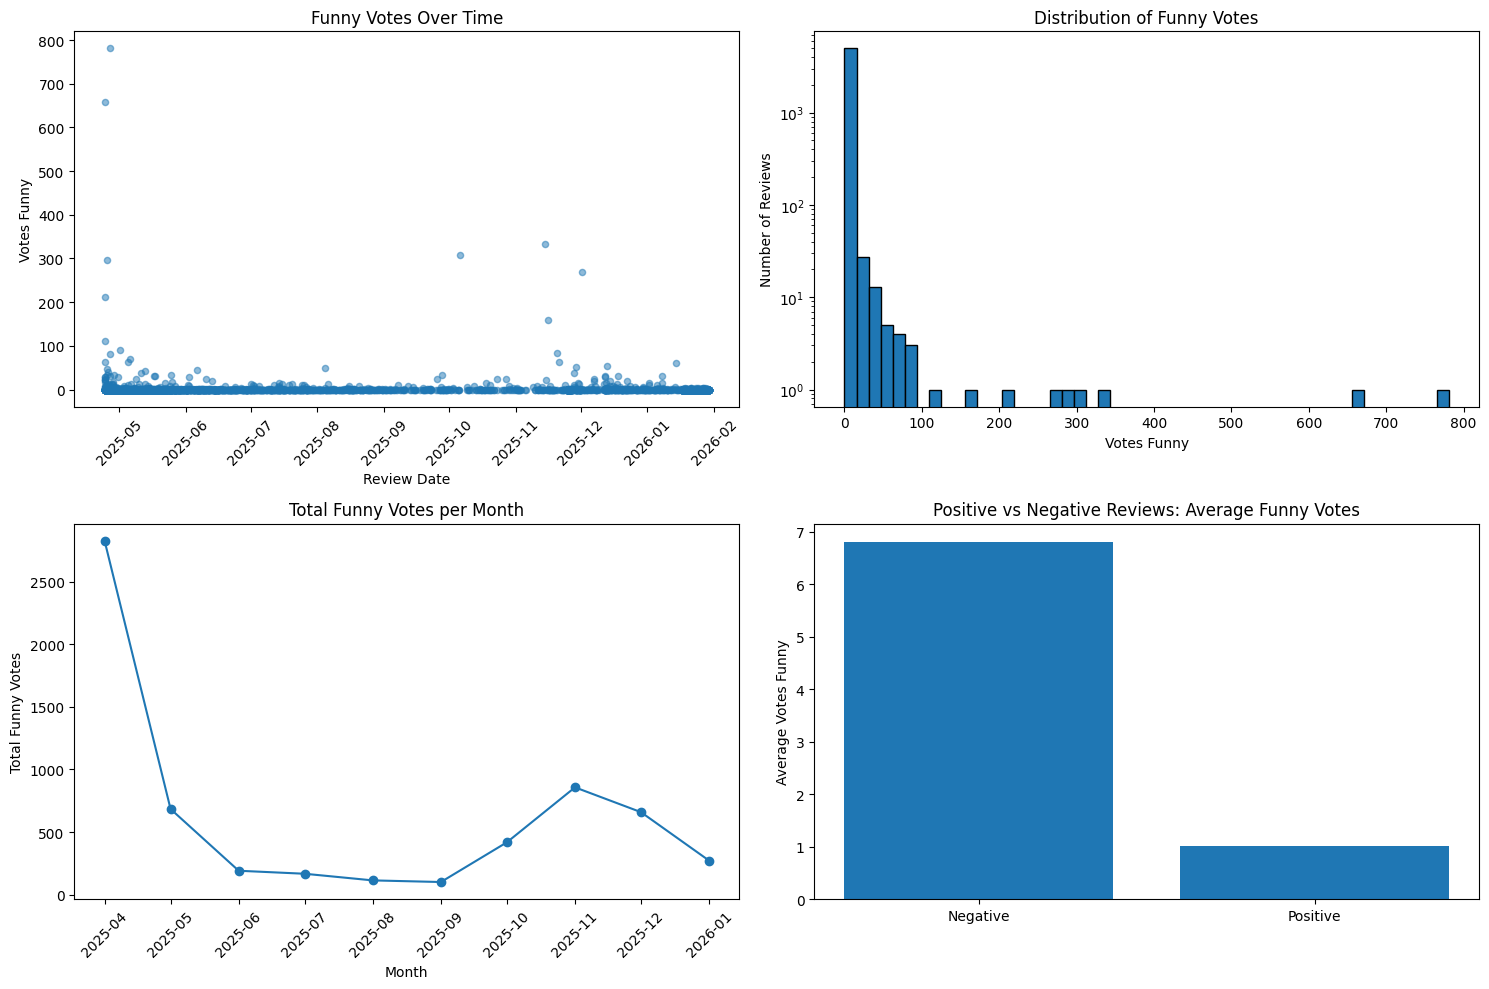


Game: Clair Obscur: Expedition 33
Reviews with funny votes (>0): 540 / 5034
Average funny votes (all reviews): 1.25
Average funny votes (reviews with >0): 11.64


In [32]:
# Timeline of funny reviews for the first game
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot: When were funny reviews created?
axes[0, 0].scatter(df['timestamp_created'], df['votes_funny'], alpha=0.5, s=20)
axes[0, 0].set_xlabel('Review Date')
axes[0, 0].set_ylabel('Votes Funny')
axes[0, 0].set_title('Funny Votes Over Time')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Distribution of funny votes (histogram)
axes[0, 1].hist(df['votes_funny'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Votes Funny')
axes[0, 1].set_ylabel('Number of Reviews')
axes[0, 1].set_title('Distribution of Funny Votes')
axes[0, 1].set_yscale('log')

# 3. Reviews by month
df['month'] = df['timestamp_created'].dt.to_period('M')
monthly_funny = df.groupby('month')['votes_funny'].agg(['count', 'sum', 'mean'])
monthly_funny.index = monthly_funny.index.to_timestamp()
axes[1, 0].plot(monthly_funny.index, monthly_funny['sum'], marker='o')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Funny Votes')
axes[1, 0].set_title('Total Funny Votes per Month')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Positive vs Negative reviews - which get more funny votes?
voted_comparison = df.groupby('voted_up')['votes_funny'].mean()
axes[1, 1].bar(['Negative', 'Positive'], [voted_comparison[False], voted_comparison[True]])
axes[1, 1].set_ylabel('Average Votes Funny')
axes[1, 1].set_title('Positive vs Negative Reviews: Average Funny Votes')

plt.tight_layout()
plt.show()

print(f"\nGame: {app_info['name']}")
print(f"Reviews with funny votes (>0): {(df['votes_funny'] > 0).sum()} / {len(df)}")
print(f"Average funny votes (all reviews): {df['votes_funny'].mean():.2f}")
print(f"Average funny votes (reviews with >0): {df[df['votes_funny'] > 0]['votes_funny'].mean():.2f}")


C:\Users\maoka\AppData\Local\Temp\ipykernel_24844\2565924455.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby(['age_bin', 'is_funny'])['votes_up'].mean().unstack()


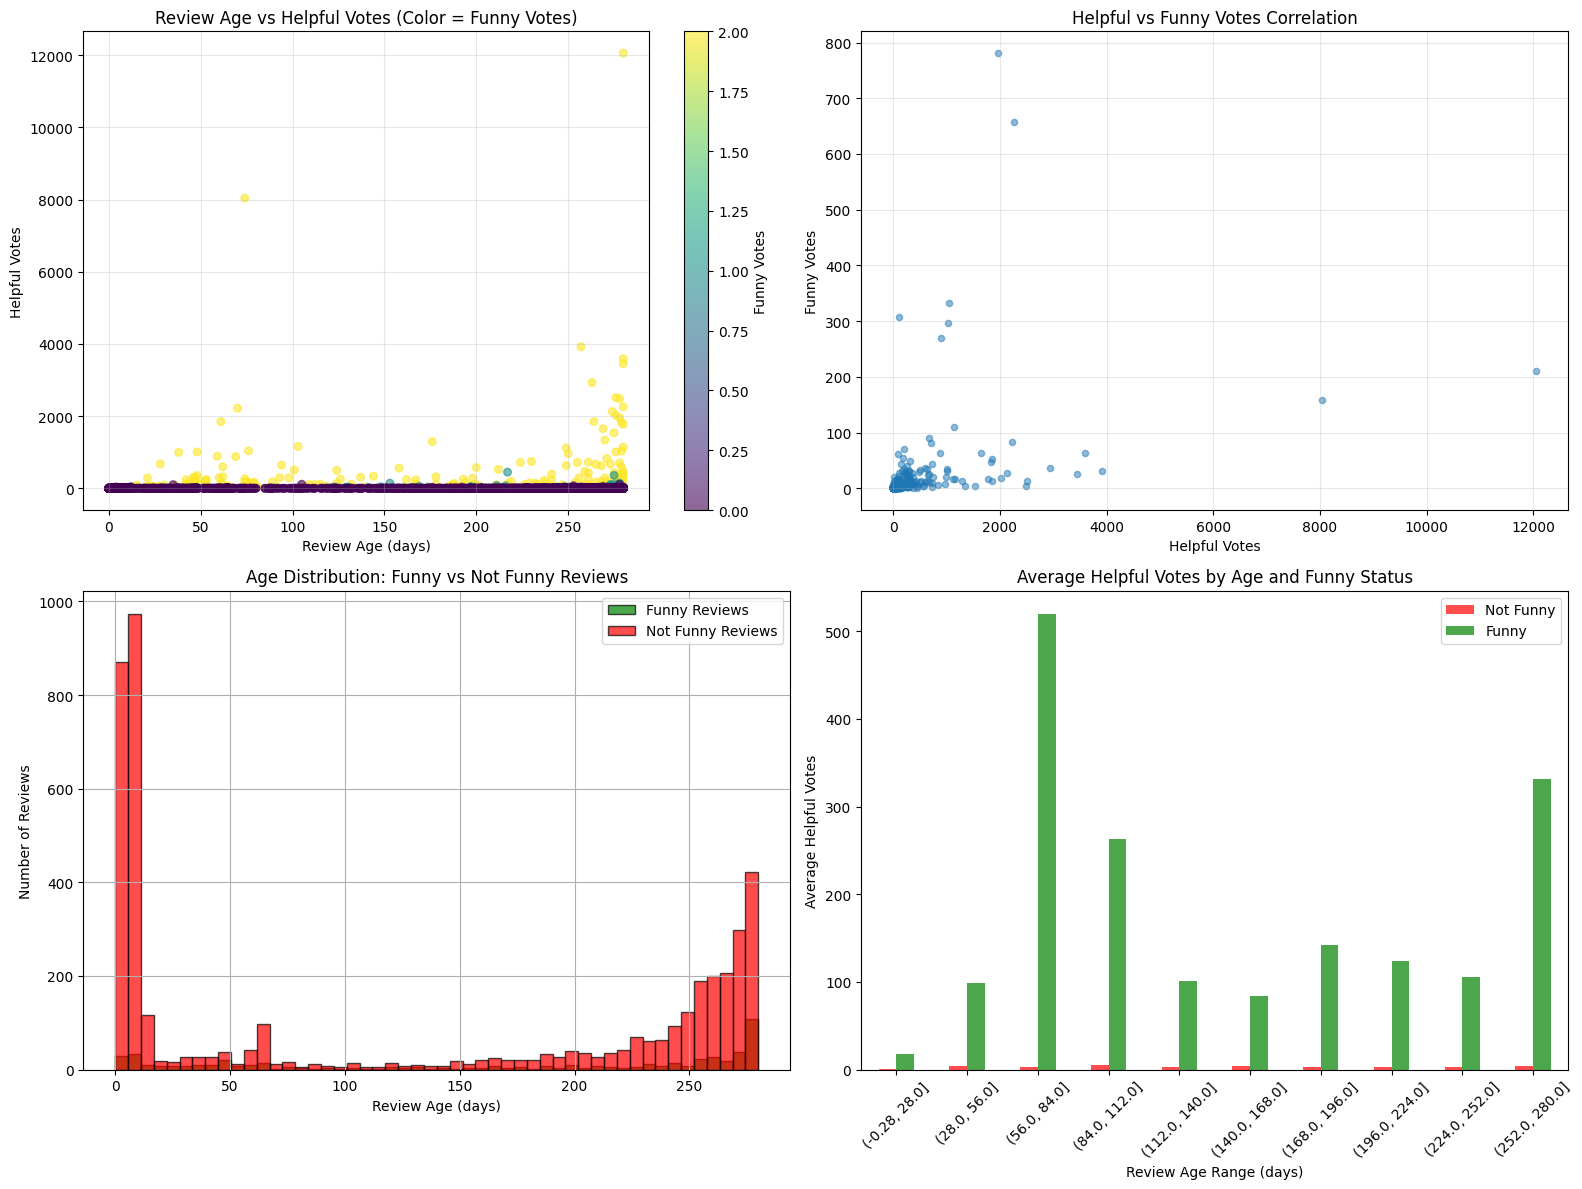

In [35]:
# Calculate review age in days
df['review_age_days'] = (pd.Timestamp.now() - df['timestamp_created']).dt.days

# Create color mapping: green if funny votes > 0, red otherwise
df['is_funny'] = df['votes_funny'] > 0

# Create the scatter plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age vs Helpful votes with funny votes color scale
scatter = axes[0, 0].scatter(df['review_age_days'], df['votes_up'], 
                             c=df['votes_funny'], cmap='viridis', alpha=0.6, s=30, 
                             norm=plt.Normalize(vmin=0, vmax=df['votes_funny'].quantile(0.95)))
axes[0, 0].set_xlabel('Review Age (days)')
axes[0, 0].set_ylabel('Helpful Votes')
axes[0, 0].set_title('Review Age vs Helpful Votes (Color = Funny Votes)')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 0], label='Funny Votes')

# 2. Helpful votes vs Funny votes correlation
axes[0, 1].scatter(df['votes_up'], df['votes_funny'], alpha=0.5, s=20)
axes[0, 1].set_xlabel('Helpful Votes')
axes[0, 1].set_ylabel('Funny Votes')
axes[0, 1].set_title('Helpful vs Funny Votes Correlation')
axes[0, 1].grid(True, alpha=0.3)

# 3. Review age distribution by funny/not funny
df[df['is_funny']]['review_age_days'].hist(ax=axes[1, 0], bins=50, alpha=0.7, 
                                            color='green', label='Funny Reviews', edgecolor='black')
df[~df['is_funny']]['review_age_days'].hist(ax=axes[1, 0], bins=50, alpha=0.7, 
                                             color='red', label='Not Funny Reviews', edgecolor='black')
axes[1, 0].set_xlabel('Review Age (days)')
axes[1, 0].set_ylabel('Number of Reviews')
axes[1, 0].set_title('Age Distribution: Funny vs Not Funny Reviews')
axes[1, 0].legend()

# 4. Average helpful votes by age bins
df['age_bin'] = pd.cut(df['review_age_days'], bins=10)
age_analysis = df.groupby(['age_bin', 'is_funny'])['votes_up'].mean().unstack()
age_analysis.plot(kind='bar', ax=axes[1, 1], color=['red', 'green'], alpha=0.7)
axes[1, 1].set_xlabel('Review Age Range (days)')
axes[1, 1].set_ylabel('Average Helpful Votes')
axes[1, 1].set_title('Average Helpful Votes by Age and Funny Status')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(['Not Funny', 'Funny'])

plt.tight_layout()
plt.show()


## Statistical Analysis: Age, Helpfulness, and Humor

In [38]:
# Correlation analysis
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)
correlation_data = df[['review_age_days', 'votes_up', 'votes_funny']].corr()
print("\nCorrelation Matrix:")
print(correlation_data)

# Statistical comparison: Funny vs Not Funny reviews
print("\n" + "=" * 60)
print("FUNNY vs NOT FUNNY REVIEWS COMPARISON")
print("=" * 60)

comparison_stats = pd.DataFrame({
    'Funny Reviews': [
        df[df['is_funny']].shape[0],
        df[df['is_funny']]['votes_up'].mean(),
        df[df['is_funny']]['votes_up'].median(),
        df[df['is_funny']]['review_age_days'].mean(),
        df[df['is_funny']]['votes_funny'].mean()
    ],
    'Not Funny Reviews': [
        df[~df['is_funny']].shape[0],
        df[~df['is_funny']]['votes_up'].mean(),
        df[~df['is_funny']]['votes_up'].median(),
        df[~df['is_funny']]['review_age_days'].mean(),
        0
    ]
}, index=['Count', 'Avg Helpful Votes', 'Median Helpful Votes', 'Avg Age (days)', 'Avg Funny Votes'])

print(comparison_stats)

# Age-based analysis
print("\n" + "=" * 60)
print("AGE-BASED BREAKDOWN")
print("=" * 60)

age_categories = pd.cut(df['review_age_days'], 
                        bins=[0, 30, 90, 180, 365, float('inf')],
                        labels=['0-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days'])

age_breakdown = df.groupby(age_categories).agg({
    'recommendationid': 'count',
    'votes_up': 'mean',
    'votes_funny': 'mean',
    'is_funny': lambda x: (x.sum() / len(x) * 100)
}).round(2)

age_breakdown.columns = ['Review Count', 'Avg Helpful', 'Avg Funny', '% with Funny Votes']
print(age_breakdown)

# Top funny reviews analysis
print("\n" + "=" * 60)
print("TOP 10 FUNNY REVIEWS - CHARACTERISTICS")
print("=" * 60)

top_funny = df.nlargest(10, 'votes_funny')[['votes_funny', 'votes_up', 'review_age_days', 'voted_up']]
top_funny['voted_up'] = top_funny['voted_up'].map({True: 'Positive', False: 'Negative'})
print(top_funny)


CORRELATION ANALYSIS

Correlation Matrix:
                 review_age_days  votes_up  votes_funny
review_age_days         1.000000  0.064273     0.038294
votes_up                0.064273  1.000000     0.423869
votes_funny             0.038294  0.423869     1.000000

FUNNY vs NOT FUNNY REVIEWS COMPARISON
                      Funny Reviews  Not Funny Reviews
Count                    540.000000        4494.000000
Avg Helpful Votes        209.461111           2.326880
Median Helpful Votes      11.000000           2.000000
Avg Age (days)           169.661111         125.431019
Avg Funny Votes           11.644444           0.000000

AGE-BASED BREAKDOWN
                 Review Count  Avg Helpful  Avg Funny  % with Funny Votes
review_age_days                                                          
0-30 days                1998         1.49       0.14                4.40
31-90 days                387        62.83       3.89               22.48
91-180 days               260        36.41      

C:\Users\maoka\AppData\Local\Temp\ipykernel_24844\4205008888.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_breakdown = df.groupby(age_categories).agg({
C:\Users\maoka\AppData\Local\Temp\ipykernel_24844\4205008888.py:46: RuntimeWarning: invalid value encountered in scalar divide
  'is_funny': lambda x: (x.sum() / len(x) * 100)


In [39]:
# Detailed cross-tabulation
print("=" * 60)
print("HELPFULNESS CATEGORIES vs FUNNY STATUS")
print("=" * 60)

# Create helpfulness categories
df['helpful_category'] = pd.cut(df['votes_up'], 
                                 bins=[-1, 0, 5, 20, 100, float('inf')],
                                 labels=['No Helpful', '1-5 Helpful', '6-20 Helpful', '21-100 Helpful', '100+ Helpful'])

crosstab = pd.crosstab(df['helpful_category'], df['is_funny'], 
                       values=df['votes_funny'], aggfunc='mean', margins=True)
crosstab.columns = ['Not Funny', 'Has Funny Votes', 'Total']
print("\nAverage Funny Votes by Helpfulness Category:")
print(crosstab.round(2))

# Distribution table
print("\n" + "=" * 60)
distribution_table = pd.crosstab(df['helpful_category'], df['is_funny'], margins=True)
distribution_table.columns = ['Not Funny', 'Has Funny Votes', 'Total']
print("\nCount Distribution:")
print(distribution_table)


HELPFULNESS CATEGORIES vs FUNNY STATUS

Average Funny Votes by Helpfulness Category:
                  Not Funny  Has Funny Votes  Total
helpful_category                                   
No Helpful              0.0             1.40   0.02
1-5 Helpful             0.0             1.25   0.07
6-20 Helpful            0.0             1.64   0.44
21-100 Helpful          0.0             4.43   3.58
100+ Helpful            0.0            37.01  36.28
All                     0.0            11.64   1.25


Count Distribution:
                  Not Funny  Has Funny Votes  Total
helpful_category                                   
No Helpful             1178               20   1198
1-5 Helpful            3032              190   3222
6-20 Helpful            260               94    354
21-100 Helpful           21               88    109
100+ Helpful              3              148    151
All                    4494              540   5034
